# Проект для «Викишоп»

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

Обучите модель классифицировать комментарии на позитивные и негативные. В вашем распоряжении набор данных с разметкой о токсичности правок.

Постройте модель со значением метрики качества *F1* не меньше 0.75. 

## Импорты библиотек

In [1]:
import pandas as pd

import numpy as np

from scipy.stats import randint, uniform

import matplotlib.pyplot as plt

import re 

import nltk
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer 
from nltk.corpus import stopwords as nltk_stopwords

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score,
    precision_recall_curve,
    PrecisionRecallDisplay,
    recall_score,
    precision_score
)

from time import time

RANDOM_STATE = 1042

## Подготовка

In [2]:
df = pd.read_csv('/datasets/toxic_comments.csv')
df.drop('Unnamed: 0', axis=1, inplace=True)

### Общая информация

In [3]:
df.head()

,text,toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ MB


In [5]:
df.duplicated().sum()

0

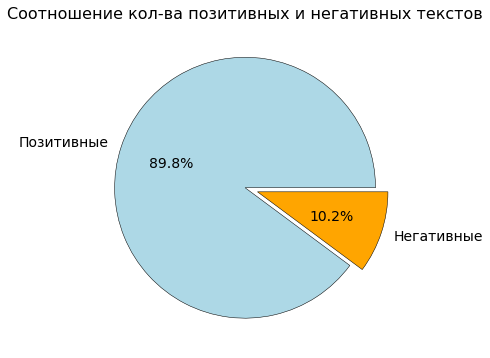

In [6]:
plt.figure(figsize=(8,6))
plt.title('Соотношение кол-ва позитивных и негативных текстов', fontsize=16)
plt.pie(
    df.toxic.value_counts().values, 
    labels=['Позитивные', 'Негативные'],
    explode=(0, 0.1),
    autopct='%1.1f%%',
    textprops={'fontsize':14},
    colors=['lightblue', 'orange'],
    wedgeprops={'lw':0.5, 'ls':'-', 'edgecolor':'k'}
);

**Вывод:** для разработки модели, способной классифицировать комментарии на позитивные и негативные, передан датасет, состоящий из 159_292 комментариев на английском языке, определенных как позитивные или негативные. При этом наблюдается серьезный дисбаланс классов - позитивных текстов почти в 9 раз больше, чем негативных. Дубликатов и пропусков в данных не обнаружилось.

### Обработка текстов

In [8]:
def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {
        'J': wordnet.ADJ,
        'N': wordnet.NOUN,
        'V': wordnet.VERB,
        'R': wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)

In [9]:
m = WordNetLemmatizer()

def get_clean_lemm_text(text):
    pattern = re.sub(r'[^a-z ]', ' ', text.lower()) 
    clean_text = ' '.join(pattern.split())
    
    word_list = nltk.word_tokenize(clean_text)
    lemm_list = [m.lemmatize(w, get_wordnet_pos(w)) for w in word_list]
    lemm_text = ' '.join(lemm_list)
    return lemm_text


df['clean_lemm_text'] = df['text'].apply(get_clean_lemm_text)
df.head()

,text,toxic,clean_lemm_text
0,Explanation\nWhy the edits made under my usern...,0,explanation why the edits make under my userna...
1,D'aww! He matches this background colour I'm s...,0,d aww he match this background colour i m seem...
2,"Hey man, I'm really not trying to edit war. It...",0,hey man i m really not try to edit war it s ju...
3,"""\nMore\nI can't make any real suggestions on ...",0,more i can t make any real suggestion on impro...
4,"You, sir, are my hero. Any chance you remember...",0,you sir be my hero any chance you remember wha...


In [10]:
features = df['clean_lemm_text']
target = df['toxic']

features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.1, random_state=RANDOM_STATE, stratify = target)

In [11]:
print(
    'Соотношение классов во всем датасете:', 
    round(df.loc[df.toxic == 0, 'toxic'].count() / df.loc[df.toxic == 1, 'toxic'].count(), 2),
    '\n\nРазмер features_train:', 
    features_train.shape[0],
    '\nРазмер target_train:', 
    target_train.shape[0],
    '\nСоотношение классов в target_train:', 
    round(sum(target_train == 0) / sum(target_train == 1), 2),
    '\n\nРазмер features_test:', 
    features_test.shape[0],
    '\nРазмер target_test:', 
    target_test.shape[0],
    '\nСоотношение классов в target_test:', 
    round(sum(target_test == 0) / sum(target_test == 1), 2)
)

Соотношение классов во всем датасете: 8.84 

Размер features_train: 143362 
Размер target_train: 143362 
Соотношение классов в target_train: 8.84 

Размер features_test: 15930 
Размер target_test: 15930 
Соотношение классов в target_test: 8.84


In [13]:
corpus_train = features_train.values
corpus_test = features_test.values

In [14]:
stopwords = nltk_stopwords.words('english')

TfidfV = TfidfVectorizer(stop_words=stopwords)

tf_idf_train = TfidfV.fit_transform(corpus_train)
tf_idf_test = TfidfV.transform(corpus_test)

print(
    'tf_idf_train:', tf_idf_train.shape,
    '\ntf_idf_test:', tf_idf_test.shape
)

tf_idf_train: (143362, 142662) 
tf_idf_test: (15930, 142662)


## Обучение

Рассмотрим 3 вида моделей:
- логистическую регрессию (линейная модель)
- дерево решений ("деревянная модель")
- ~~catboost (модель градиентного бустинга)~~
- случайный лес ("деревянная модель")

В качестве метрики будем использовать `f1-score`, она применяется в задаче классификации (наша задача такая), описывает сразу два показателя качества модели - полноту и точность. Полнота выявляет, какую долю положительных среди всех ответов выделила модель, а точность - определяет, как много отрицательных ответов нашла модель, пока искала положительные. Таким образом, показатель F1-меры дает более полную оценку качества модели.

In [15]:
result_values = pd.DataFrame(columns=['model', 'time_fit', 'time_pred', 'f1_score'])
result_values

,model,time_fit,time_pred,f1_score


**LogisticRegression**

In [18]:
%%time
pipe_LR = Pipeline(
    [
        ('tfidf', TfidfVectorizer(stop_words=stopwords)), 
        ('lr', LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            max_iter=1000, 
            class_weight='balanced'
         )
        )
    ]
)

parameters_LR = {'lr__C': range(5, 16)}

gscv_model_LR = GridSearchCV(
    pipe_LR, 
    parameters_LR, 
    scoring='f1', 
    n_jobs=-1, 
    cv=5
)

gscv_model_LR.fit(corpus_train, target_train)

CPU times: user 17min 15s, sys: 11min 11s, total: 28min 27s
Wall time: 28min 27s


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(stop_words=['i', 'me',
                                                                    'my',
                                                                    'myself',
                                                                    'we', 'our',
                                                                    'ours',
                                                                    'ourselves',
                                                                    'you',
                                                                    "you're",
                                                                    "you've",
                                                                    "you'll",
                                                                    "you'd",
                                                                    'your',
 

In [19]:
LR_best_model = gscv_model_LR.best_estimator_
LR_best_result = gscv_model_LR.best_score_

print('Лучшие параметры:', gscv_model_LR.best_params_)
print('Лучший результат:', LR_best_result)

Лучшие параметры: {'lr__C': 6}
Лучший результат: 0.7561540033566556


In [20]:
start_fit_LR = time()
LR_best_model.fit(corpus_train, target_train)
end_fit_RL = time()

time_fit_LR = round(end_fit_RL - start_fit_LR, 2)
print(f'time_fit_LR = {time_fit_LR} sec')

time_fit_LR = 30.08 sec


In [21]:
start_pred_LR = time()
LR_best_model.predict(corpus_train)
end_pred_RL = time()

time_pred_LR = round(end_pred_RL - start_pred_LR, 2)
print(f'time_pred_LR = {time_pred_LR} sec')

time_pred_LR = 5.53 sec


In [22]:
new_row = {
    'model': 'LR', 
    'time_fit': time_fit_LR,
    'time_pred': time_pred_LR,
    'f1_score': round(LR_best_result, 2)
}

result_values = result_values.append(new_row, ignore_index=True)

**DecisionTreeClassifier**

In [25]:
%%time
pipe_DTC = Pipeline(
    [
        ('tfidf', TfidfVectorizer(stop_words=stopwords)), 
        ('dtc', DecisionTreeClassifier(
            random_state=RANDOM_STATE,  
            class_weight='balanced'
         )
        )
    ]
)

parameters_DTC = {'dtc__max_depth': range(1, 16)}

gscv_model_DTC = GridSearchCV(
    pipe_DTC, 
    parameters_DTC, 
    scoring='f1', 
    n_jobs=-1, 
    cv=5
)

gscv_model_DTC.fit(corpus_train, target_train)

CPU times: user 12min 42s, sys: 9.62 s, total: 12min 51s
Wall time: 12min 52s


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(stop_words=['i', 'me',
                                                                    'my',
                                                                    'myself',
                                                                    'we', 'our',
                                                                    'ours',
                                                                    'ourselves',
                                                                    'you',
                                                                    "you're",
                                                                    "you've",
                                                                    "you'll",
                                                                    "you'd",
                                                                    'your',
 

In [26]:
DTC_best_model = gscv_model_DTC.best_estimator_
DTC_best_result = gscv_model_DTC.best_score_

print('Лучшие параметры:', gscv_model_DTC.best_params_)
print('Лучший результат:', DTC_best_result)

Лучшие параметры: {'dtc__max_depth': 14}
Лучший результат: 0.6050499556830315


In [27]:
start_fit_DTC = time()
DTC_best_model.fit(corpus_train, target_train)
end_fit_DTC = time()

time_fit_DTC = round(end_fit_DTC - start_fit_DTC, 2)
print(f'time_fit_RFC = {time_fit_DTC} sec')

time_fit_RFC = 16.73 sec


In [28]:
start_pred_DTC = time()
DTC_best_model.predict(corpus_train)
end_pred_DTC = time()

time_pred_DTC = round(end_pred_DTC - start_pred_DTC, 2)
print(f'time_pred_RFC = {time_pred_DTC} sec')

time_pred_RFC = 5.59 sec


In [29]:
new_row = {
    'model': 'DTC', 
    'time_fit': time_fit_DTC,
    'time_pred': time_pred_DTC,
    'f1_score': round(DTC_best_result, 2)
}

result_values = result_values.append(new_row, ignore_index=True)

**RandomForestClassifier**

In [40]:
%%time
pipe_RFC = Pipeline(
    [
        ('tfidf', TfidfVectorizer(stop_words=stopwords)), 
        ('rfc', RandomForestClassifier(
            random_state=RANDOM_STATE,  
            class_weight='balanced'
         )
        )
    ]
)

parameters_RFC = {
    'rfc__n_estimators': range(100, 151, 10),
    'rfc__max_depth': range(1, 16)
}

rscv_model_RFC = RandomizedSearchCV(
    pipe_RFC, 
    parameters_RFC, 
    scoring='f1', 
    n_iter=10,
    n_jobs=-1, 
    cv=5,
    random_state=RANDOM_STATE
)

rscv_model_RFC.fit(corpus_train, target_train)

CPU times: user 8min 22s, sys: 4.92 s, total: 8min 27s
Wall time: 8min 28s


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('tfidf',
                                              TfidfVectorizer(stop_words=['i',
                                                                          'me',
                                                                          'my',
                                                                          'myself',
                                                                          'we',
                                                                          'our',
                                                                          'ours',
                                                                          'ourselves',
                                                                          'you',
                                                                          "you're",
                                                                          "you've",
                  

In [41]:
RFC_best_model = rscv_model_RFC.best_estimator_
RFC_best_result = rscv_model_RFC.best_score_

print('Лучшие параметры:', rscv_model_RFC.best_params_)
print('Лучший результат:', RFC_best_result)

Лучшие параметры: {'rfc__n_estimators': 140, 'rfc__max_depth': 15}
Лучший результат: 0.38368877121652145


In [42]:
start_fit_RFC = time()
RFC_best_model.fit(corpus_train, target_train)
end_fit_RFC = time()

time_fit_RFC = round(end_fit_RFC - start_fit_RFC, 2)
print(f'time_fit_RFC = {time_fit_RFC} sec')

time_fit_RFC = 14.27 sec


In [43]:
start_pred_RFC = time()
RFC_best_model.predict(corpus_train)
end_pred_RFC = time()

time_pred_RFC = round(end_pred_RFC - start_pred_RFC, 2)
print(f'time_pred_RFC = {time_pred_RFC} sec')

time_pred_RFC = 8.37 sec


In [44]:
new_row = {
    'model': 'RFC', 
    'time_fit': time_fit_RFC,
    'time_pred': time_pred_RFC,
    'f1_score': round(RFC_best_result, 2)
}

result_values = result_values.append(new_row, ignore_index=True)

## Выводы

In [45]:
result_values

,model,time_fit,time_pred,f1_score
0,LR,30.08,5.53,0.76
1,DTC,16.73,5.59,0.61
2,RFC,14.27,8.37,0.38


Условие задачи смогла выполнить только одна модель - логистическая регрессия, ее метрика составила 0.76. Проверим ее на тестовых данных.

In [46]:
predict = LR_best_model.predict(corpus_test)

In [47]:
result_tets = f1_score(target_test, predict)
print('F1 на тестовой выборке:', round(result_tets, 2))

F1 на тестовой выборке: 0.76


In [48]:
recall = recall_score(target_test, predict)
precision = precision_score(target_test, predict)

print(
    'Recall:', round(recall, 2),
    '\nPrecision:', round(precision, 2)
)

Recall: 0.83 
Precision: 0.7


In [49]:
precision_dsp, recall_dsp, _ = precision_recall_curve(target_test, predict)
pre_rec_dsp = PrecisionRecallDisplay(precision=precision_dsp, recall=recall_dsp)

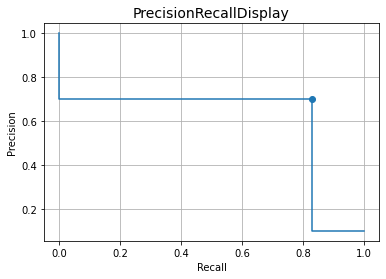

In [50]:
pre_rec_dsp.plot()
plt.scatter(recall, precision)
plt.title('PrecisionRecallDisplay', fontsize=14)
plt.grid()
plt.show();

Значение метрики f1 на тестовых данных составила так же 0.76. Так же модель имеет достаточно высокое значение полноты, то есть она хорошо ищет положительные объекты - в нашем случае негативные отзывы - особо важное качество для нашей модели, значение точности неплохое - есть осечки в сторону ложноположительных объектов (модель считает отзыв негативным, а на самом деле он позитивный) - над этим можно еще поработать.

**Общий вывод:**

Для разработки модели, способной классифицировать комментарии на позитивные и негативные, передан датасет, состоящий из 159_292 комментариев на английском языке, определенных как позитивные или негативные. При этом наблюдается серьезный дисбаланс классов - позитивных текстов почти в 9 раз больше, чем негативных. Дубликатов и пропусков в данных не обнаружилось.

В работе было рассмотрено 3 вида моделей:
- логистическую регрессию (линейная модель)
- дерево решений ("деревянная модель")
- случайный лес ("деревянная модель")

В качестве метрики использована `f1-score`, она применяется в задаче классификации (наша задача такая), описывает сразу два показателя качества модели - полноту и точность. Полнота выявляет, какую долю положительных среди всех ответов выделила модель, а точность - определяет, как много отрицательных ответов нашла модель, пока искала положительные. Таким образом, показатель F1-меры дает более полную оценку качества модели.

Условие задачи смогла выполнить только одна модель - логистическая регрессия, ее метрика составила 0.76. На тестовых данных она показала такой же результат. Модель имеет достаточно высокое значение полноты, то есть она хорошо ищет положительные объекты - в нашем случае негативные отзывы - особо важное качество для нашей модели, значение точности неплохое - есть осечки в сторону ложноположительных объектов (модель считает отзыв негативным, а на самом деле он позитивный) - над этим можно еще поработать.